# Scaled time pressure analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import chess
import chess.engine
import os

In [2]:
# Functions for converting Stockfish results to win probability
from compute_move_voc import *

# Functions for computing VOC
from convert_stockfish_scores import *

In [3]:
# Increase font size a bit
plt.rcParams.update({'font.size': 16})

## Setup

In [4]:
# Load the data
freq_data = pd.read_csv('/Users/ionatankuperwajs/Desktop/CoCoSci/Chess/Data/Time/final_freq.csv')

In [5]:
# Format the data correctly
freq_data = freq_data.head(201)
# freq_data = freq_data.drop(20).reset_index()
# freq_data = freq_data.drop(99).reset_index()
freq_data = freq_data.rename(columns={"board_position": "board", "player_white": "white_active"})
freq_data['move_ply'] = [30] * 201
freq_data['game_id'] = list(range(1, 202))

# Add the active player to the fen
positions = []
count = 0
for fen in freq_data['board'].values:
    if freq_data.iloc[count]['white_active'] == True:
        positions.append(fen+' w')
    elif freq_data.iloc[count]['white_active'] == False:
        positions.append(fen+' b')
    count += 1
    
freq_data['board'] = positions
freq_data

,board,white_active,frequency,move_ply,game_id
0,r2qk2r/pp3pp1/2pbpn1p/7P/3P4/5N2/PPPBQPP1/2KR3R b,False,26398,30,1
1,r1b2rk1/5ppp/p1pb4/1p1n4/3P4/1BP2QPq/PP3P1P/RN...,False,22868,30,2
2,r1b2rk1/5ppp/p1pb4/1p1n4/3P4/1BP1B1Pq/PP3P1P/R...,False,22756,30,3
3,r4rk1/5ppp/p1pb4/1p1n4/3P2b1/1BP2QPq/PP3P1P/RN...,True,21948,30,4
4,r4rk1/5ppp/p1pb4/1p1n4/3P2b1/1BP3Pq/PP3PQP/RNB...,False,21712,30,5
...,...,...,...,...,...
196,r3qrk1/3n2pp/p2p1b2/Np1Pp2n/8/4BP2/PPPQ3P/2KR1...,True,1144,30,197
197,r2q1rk1/2p1bppp/p7/1p2Pb2/3P4/1P1pB3/1P3PPP/RB...,False,1136,30,198
198,2kr1b1r/ppq2pp1/2p1pn1p/7P/3P4/5N2/PPPBQPP1/1K...,False,1128,30,199
199,2rq3r/p2bbpkp/1pn1p1p1/3pP2P/5B2/2P5/P2NQPP1/1...,True,1119,30,200


In [6]:
# Set up storage for results
d1_move = []
d15_move = []
d1_score = []
d15_score = []
vocs = []

# Set up the engine
stockfish_path = '/opt/homebrew/opt/stockfish/bin/stockfish'
engine = chess.engine.SimpleEngine.popen_uci(stockfish_path)

# Set up to which depth is included in the consideration set
limit_dict = {'type': 'depth', 'val': 16}

# What depths to evaluate moves at
eval_depths_arr = np.array([15])

In [7]:
# Compute the VOC for all moves
n_moves = freq_data.shape[0]
for move in range(n_moves):
    move_df = freq_data.loc[move]
    depths_sel_and_eval_df, board_score_dict = comp_moves_at_depth_and_eval(move_df, engine, limit_dict, eval_depths_arr)
    voc = compute_voc(depths_sel_and_eval_df)
    d1_move.append(depths_sel_and_eval_df['move'][0])
    d15_move.append(depths_sel_and_eval_df['move'][15])
    d1_score.append(depths_sel_and_eval_df['score_wp_active'][0])
    d15_score.append(depths_sel_and_eval_df['score_wp_active'][15])
    vocs.append(voc)

In [8]:
# Add these to the dataframe
freq_data['depth_1'] = d1_move
freq_data['depth_15'] = d15_move
freq_data['score_1'] = d1_score
freq_data['score_15'] = d15_score
freq_data['voc'] = vocs
freq_data

,board,white_active,frequency,move_ply,game_id,depth_1,depth_15,score_1,score_15,voc
0,r2qk2r/pp3pp1/2pbpn1p/7P/3P4/5N2/PPPBQPP1/2KR3R b,False,26398,30,1,d8c7,a7a5,-0.552369,-0.550166,0.002754
1,r1b2rk1/5ppp/p1pb4/1p1n4/3P4/1BP2QPq/PP3P1P/RN...,False,22868,30,2,c8g4,c8g4,-0.475205,-0.475205,0.000000
2,r1b2rk1/5ppp/p1pb4/1p1n4/3P4/1BP1B1Pq/PP3P1P/R...,False,22756,30,3,c8g4,a8a7,-0.498008,-0.488547,0.009461
3,r4rk1/5ppp/p1pb4/1p1n4/3P2b1/1BP2QPq/PP3P1P/RN...,True,21948,30,4,f3g2,f3g2,0.470210,0.470210,0.000000
4,r4rk1/5ppp/p1pb4/1p1n4/3P2b1/1BP3Pq/PP3PQP/RNB...,False,21712,30,5,a8e8,h3h5,-0.522486,-0.471319,0.051167
...,...,...,...,...,...,...,...,...,...,...
196,r3qrk1/3n2pp/p2p1b2/Np1Pp2n/8/4BP2/PPPQ3P/2KR1...,True,1144,30,197,f1h3,f1h3,0.486878,0.486878,0.029495
197,r2q1rk1/2p1bppp/p7/1p2Pb2/3P4/1P1pB3/1P3PPP/RB...,False,1136,30,198,c7c5,c7c5,-0.491885,-0.491885,0.000000
198,2kr1b1r/ppq2pp1/2p1pn1p/7P/3P4/5N2/PPPBQPP1/1K...,False,1128,30,199,f8d6,d8d5,-0.524153,-0.541334,0.000000
199,2rq3r/p2bbpkp/1pn1p1p1/3pP2P/5B2/2P5/P2NQPP1/1...,True,1119,30,200,f4h6,d2f3,0.439850,0.499678,0.112518


In [9]:
# Path to the folder containing all moves/games
data_folder = '/Users/ionatankuperwajs/Desktop/CoCoSci/Chess/Data/Time/Data/'

# Number of positions
num_positions = 200

# Board positions as fens
fens = freq_data['board'].tolist()

# Color for the active player
player_color = freq_data['white_active'].map({True: 'white', False: 'black'}).tolist()

# Set time controls
valid_controls = ['60+0', '120+1', '180+0', '180+2', '300+0', '300+3',
                  '600+0', '600+5', '900+10', '1800+0', '1800+20']
xvals = range(len(valid_controls))

## Load the data

In [10]:
# Load all moves and games
all_moves = {}
all_games = {}

for i in range(num_positions):
    moves_path = os.path.join(data_folder, f'moves{i}.csv')
    games_path = os.path.join(data_folder, f'games{i}.csv')
    all_moves[i] = pd.read_csv(moves_path)
    all_games[i] = pd.read_csv(games_path)

In [11]:
# Display a sample moves table
all_moves[0]

,gid,move_ply,move_uci,move_time,player_white,player_clock_time,opponent_clock_time,board_position,castling_rights,en_passant_targets,halfmove_clock,n_possible_moves,n_pieces,player_in_check,partition
0,202201001092796,30,d8b6,6.0,False,155.0,167.0,r2qk2r/pp3pp1/2pbpn1p/7P/3P4/5N2/PPPBQPP1/2KR3R,kq,NaN,2,42,26,False,202201
1,202201001095295,30,c6c5,5.0,False,160.0,171.0,r2qk2r/pp3pp1/2pbpn1p/7P/3P4/5N2/PPPBQPP1/2KR3R,kq,NaN,2,42,26,False,202201
2,202201001110092,30,d8e7,1.0,False,192.0,195.0,r2qk2r/pp3pp1/2pbpn1p/7P/3P4/5N2/PPPBQPP1/2KR3R,kq,NaN,2,42,26,False,202201
3,202201001300759,30,d8c7,1.0,False,185.0,190.0,r2qk2r/pp3pp1/2pbpn1p/7P/3P4/5N2/PPPBQPP1/2KR3R,kq,NaN,2,42,26,False,202201
4,202201001376707,32,d8c7,6.0,False,1720.0,1637.0,r2qk2r/pp3pp1/2pbpn1p/7P/3P4/5N2/PPPBQPP1/2KR3R,kq,NaN,2,42,26,False,202201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20183,202309093855899,30,d8c7,4.0,False,286.0,292.0,r2qk2r/pp3pp1/2pbpn1p/7P/3P4/5N2/PPPBQPP1/2KR3R,kq,NaN,2,42,26,False,202309
20184,202309093886900,30,d8c7,0.0,False,172.0,170.0,r2qk2r/pp3pp1/2pbpn1p/7P/3P4/5N2/PPPBQPP1/2KR3R,kq,NaN,2,42,26,False,202309
20185,202309094112736,30,d8c7,4.0,False,576.0,581.0,r2qk2r/pp3pp1/2pbpn1p/7P/3P4/5N2/PPPBQPP1/2KR3R,kq,NaN,2,42,26,False,202309
20186,202309094161964,30,a7a5,1.0,False,172.0,173.0,r2qk2r/pp3pp1/2pbpn1p/7P/3P4/5N2/PPPBQPP1/2KR3R,kq,NaN,2,42,26,False,202309


In [12]:
# Display a sample games table
all_games[0]

,gid,id,utc_datetime,initial_clock,clock_increment,opening,white_id,black_id,white_title,black_title,white_elo,black_elo,white_elo_change,black_elo_change,white_won,black_won,game_end_type,n_moves,partition
0,202201001092796,oOEMW6SM,2022-01-01 01:00:46,180.0,0.0,"Caro-Kann Defense: Classical Variation, Seiraw...",IamJBHarmon,sbkale,NaN,NaN,1887,1860,-7.0,6.0,False,True,Time forfeit,118,202201
1,202201001095295,NANBwuIf,2022-01-01 01:02:39,180.0,0.0,"Caro-Kann Defense: Classical Variation, Seiraw...",xBrainMeltx,HJYung,NaN,NaN,2309,2205,4.0,-4.0,True,False,Normal,33,202201
2,202201001110092,iyZhDOw3,2022-01-01 01:13:27,180.0,2.0,"Caro-Kann Defense: Classical Variation, Seiraw...",allangarcia2021,aoObi,NaN,NaN,2052,2072,-6.0,6.0,False,True,Normal,62,202201
3,202201001300759,Hy2hgkQ4,2022-01-01 03:57:17,180.0,2.0,"Caro-Kann Defense: Classical Variation, Seiraw...",ARIY7777,MYM_EXCALIBUR,NaN,NaN,2101,2094,5.0,-5.0,True,False,Time forfeit,79,202201
4,202201001376707,SC2mHHCM,2022-01-01 05:09:06,1800.0,0.0,"Caro-Kann Defense: Classical Variation, Seiraw...",evanthewalrus,shreyaskingdom981175,NaN,NaN,2121,1965,12.0,-4.0,True,False,Normal,63,202201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20182,202309093855899,gTvtUuX4,2023-09-30 20:41:06,300.0,0.0,"Caro-Kann Defense: Classical Variation, Seiraw...",JajajaQue,BKam,NaN,NaN,2044,2059,-5.0,5.0,False,True,Normal,126,202309
20183,202309093886900,vFZ8VS2s,2023-09-30 20:54:05,180.0,0.0,"Caro-Kann Defense: Classical Variation, Seiraw...",frantomas,igordm,NaN,NaN,2215,2176,-8.0,6.0,False,True,Time forfeit,170,202309
20184,202309094112736,8GeWUFNm,2023-09-30 22:47:50,600.0,0.0,"Caro-Kann Defense: Classical Variation, Seiraw...",bartol1900,josoum,NaN,NaN,1964,2023,-4.0,5.0,False,True,Normal,64,202309
20185,202309094161964,LDWb8cfV,2023-09-30 23:19:21,180.0,0.0,"Caro-Kann Defense: Classical Variation, Seiraw...",Leonid_A,WipeOutPlease,NaN,NaN,2188,2058,3.0,-4.0,True,False,Time forfeit,155,202309


In [13]:
# Merge the dataframes
all_merged = {}

for i in range(num_positions):
    all_merged[i] = pd.merge(all_games[i], all_moves[i], on='gid')

In [14]:
# Filter out bots
for i in range(num_positions):
    df = all_merged[i]
    bot_mask = (df['white_title'] == 'BOT') | (df['black_title'] == 'BOT')
    all_merged[i] = df.drop(df[bot_mask].index).reset_index(drop=True)

In [15]:
# Print row counts per position
for i in range(num_positions):
    print(f'Position {i}: {len(all_merged[i])} rows')

Position 0: 20178 rows
Position 1: 17567 rows
Position 2: 13741 rows
Position 3: 16872 rows
Position 4: 16697 rows
Position 5: 16371 rows
Position 6: 15990 rows
Position 7: 11868 rows
Position 8: 11656 rows
Position 9: 9908 rows
Position 10: 11518 rows
Position 11: 9696 rows
Position 12: 9452 rows
Position 13: 6989 rows
Position 14: 9246 rows
Position 15: 8953 rows
Position 16: 7582 rows
Position 17: 6500 rows
Position 18: 6215 rows
Position 19: 7430 rows
Position 20: 7458 rows
Position 21: 7482 rows
Position 22: 6979 rows
Position 23: 6277 rows
Position 24: 6813 rows
Position 25: 6787 rows
Position 26: 6718 rows
Position 27: 6848 rows
Position 28: 6789 rows
Position 29: 6641 rows
Position 30: 6853 rows
Position 31: 6404 rows
Position 32: 5969 rows
Position 33: 5543 rows
Position 34: 6078 rows
Position 35: 5616 rows
Position 36: 5444 rows
Position 37: 5537 rows
Position 38: 5452 rows
Position 39: 3841 rows
Position 40: 4747 rows
Position 41: 4702 rows
Position 42: 52 rows
Position 43: 

In [16]:
# Filter out positions with less than 100 data points and with less than 10 unique moves
# all_merged = {i: df for i, df in all_merged.items() if len(df) >= 150 and df['move_uci'].nunique() >= 5}
all_merged = {i: df for i, df in all_merged.items() if len(df) >= 4000}
num_positions = len(all_merged)
print(f'{num_positions} positions remaining after filtering')

53 positions remaining after filtering


In [17]:
# Print row counts per position again
for i in all_merged.keys():
    print(f'Position {i}: {len(all_merged[i])} rows')

Position 0: 20178 rows
Position 1: 17567 rows
Position 2: 13741 rows
Position 3: 16872 rows
Position 4: 16697 rows
Position 5: 16371 rows
Position 6: 15990 rows
Position 7: 11868 rows
Position 8: 11656 rows
Position 9: 9908 rows
Position 10: 11518 rows
Position 11: 9696 rows
Position 12: 9452 rows
Position 13: 6989 rows
Position 14: 9246 rows
Position 15: 8953 rows
Position 16: 7582 rows
Position 17: 6500 rows
Position 18: 6215 rows
Position 19: 7430 rows
Position 20: 7458 rows
Position 21: 7482 rows
Position 22: 6979 rows
Position 23: 6277 rows
Position 24: 6813 rows
Position 25: 6787 rows
Position 26: 6718 rows
Position 27: 6848 rows
Position 28: 6789 rows
Position 29: 6641 rows
Position 30: 6853 rows
Position 31: 6404 rows
Position 32: 5969 rows
Position 33: 5543 rows
Position 34: 6078 rows
Position 35: 5616 rows
Position 36: 5444 rows
Position 37: 5537 rows
Position 38: 5452 rows
Position 40: 4747 rows
Position 41: 4702 rows
Position 44: 5514 rows
Position 46: 5442 rows
Position 50

## Time control

In [18]:
# Extract data for all positions based on time control
pos_time_controls = {}
pos_elos = {}
pos_rts = {}
pos_moves = {}

for i in all_merged.keys():
    df = all_merged[i]
    active_color = player_color[i]
    color_col = f'{active_color}_elo'

    time_controls, elos, rts, moves = [], [], [], []

    for ind in df.index:
        initial_clock = df['initial_clock'][ind]
        increment = df['clock_increment'][ind]
        if np.isnan(initial_clock) or np.isnan(increment):
            continue
        tc = str(int(initial_clock)) + '+' + str(int(increment))
        if tc in valid_controls:
            time_controls.append(tc)
            elos.append(df[color_col][ind])
            rts.append(df['move_time'][ind])
            moves.append(df['move_uci'][ind])

    pos_time_controls[i] = time_controls
    pos_elos[i] = elos
    pos_rts[i] = rts
    pos_moves[i] = moves

In [19]:
# Compute mean move time per time control for each position
avg_rts_all = {}
sem_rts_all = {}

for i in all_merged.keys():
    rts_arr = np.asarray(pos_rts[i])
    tcs_arr = np.asarray(pos_time_controls[i])
    avg_rts, sem_rts = [], []
    for tc in valid_controls:
        subset = rts_arr[np.where(tcs_arr == tc)]
        avg_rts.append(np.nanmean(subset).item() if len(subset) > 0 else np.nan)
        sem_rts.append(stats.sem(subset).item() if len(subset) > 1 else np.nan)
    avg_rts_all[i] = avg_rts
    sem_rts_all[i] = sem_rts

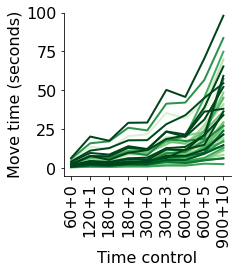

In [20]:
# Plot
fig, ax = plt.subplots(figsize=(3, 3))
cmap = plt.cm.Greens
for i in all_merged.keys():
    color = cmap(i / len(all_merged.keys()))
    ax.plot(list(xvals)[0:9], avg_rts_all[i][0:9], color=color, lw=2)
ax.set_xlabel('Time control')
ax.set_ylabel('Move time (seconds)')
ax.set_xticks(list(xvals)[0:9])
ax.set_xticklabels(valid_controls[0:9])
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylim(-5, 100)
ax.set_yticks([0, 25, 50, 75, 100])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()
# plt.savefig('move_time_scale.png', format='png', dpi=1000,bbox_inches = 'tight')

In [21]:
# Compute move entropy per time control for each position
entropy_all = {}

for i in all_merged.keys():
    tcs_arr = np.asarray(pos_time_controls[i])
    moves_arr = np.asarray(pos_moves[i])
    entropy_vals = []
    for tc in valid_controls:
        subset = moves_arr[np.where(tcs_arr == tc)]
        if len(subset) > 0:
            _, counts = np.unique(subset, return_counts=True)
            entropy_vals.append(stats.entropy(counts))
        else:
            entropy_vals.append(np.nan)
    entropy_all[i] = entropy_vals

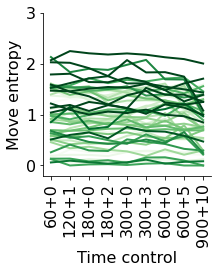

In [22]:
# Plot
fig, ax = plt.subplots(figsize=(3, 3))
cmap = plt.cm.Greens
for i in all_merged.keys():
    color = cmap(i / len(all_merged.keys()))
    ax.plot(list(xvals)[0:9], entropy_all[i][0:9], color=color, lw=2)
ax.set_xlabel('Time control')
ax.set_ylabel('Move entropy')
ax.set_xticks(list(xvals)[0:9])
ax.set_xticklabels(valid_controls[0:9])
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylim(-0.2, 3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()
# plt.savefig('move_entropy_scale.png', format='png', dpi=1000,bbox_inches = 'tight')

In [23]:
# Analyze each unique move for every position
quality_ref_all = {}

for i in all_merged.keys():
    if i >= len(fens) or not fens[i]:
        print(f'Position {i}: no FEN provided, skipping quality analysis')
        quality_ref_all[i] = {}
        continue

    board_fen = fens[i]
    unique_moves = np.unique(pos_moves[i])
    print(f'Position {i}: analysing {len(unique_moves)} unique moves')

    quality_ref = {}
    for move in unique_moves:
        new_board = chess.Board(board_fen)
        try:
            new_board.push_uci(move)
        except Exception:
            quality_ref[move] = np.nan
            continue
        engine.configure({'Clear Hash': None})
        info = engine.analyse(new_board, chess.engine.Limit(depth=15))
        score = info['score'].relative.score(mate_score=1000)
        quality_ref[move] = -score if score is not None else np.nan

    quality_ref_all[i] = quality_ref

Position 0: analysing 28 unique moves
Position 1: analysing 17 unique moves
Position 2: analysing 17 unique moves
Position 3: analysing 8 unique moves
Position 4: analysing 14 unique moves
Position 5: analysing 21 unique moves
Position 6: analysing 21 unique moves
Position 7: analysing 20 unique moves
Position 8: analysing 8 unique moves
Position 9: analysing 29 unique moves
Position 10: analysing 21 unique moves
Position 11: analysing 21 unique moves
Position 12: analysing 18 unique moves
Position 13: analysing 14 unique moves
Position 14: analysing 29 unique moves
Position 15: analysing 18 unique moves
Position 16: analysing 12 unique moves
Position 17: analysing 18 unique moves
Position 18: analysing 14 unique moves
Position 19: analysing 21 unique moves
Position 20: analysing 2 unique moves
Position 21: analysing 19 unique moves
Position 22: analysing 17 unique moves
Position 23: analysing 10 unique moves
Position 24: analysing 15 unique moves
Position 25: analysing 11 unique moves

In [24]:
# Map quality scores back to per-move lists
quality_scores_all = {}

for i in all_merged.keys():
    ref = quality_ref_all[i]
    quality_scores_all[i] = [ref.get(m, np.nan) for m in pos_moves[i]]

In [25]:
# Compute mean move quality per time control for each position
avg_quality_all = {}
sem_quality_all = {}

for i in all_merged.keys():
    tcs_arr = np.asarray(pos_time_controls[i])
    q_arr   = np.asarray(quality_scores_all[i], dtype=float)
    avg_q, sem_q = [], []
    for tc in valid_controls:
        subset = q_arr[np.where(tcs_arr == tc)]
        avg_q.append(np.nanmean(subset).item() if len(subset) > 0 else np.nan)
        sem_q.append(stats.sem(subset[~np.isnan(subset)]).item() if np.sum(~np.isnan(subset)) > 1 else np.nan)
    avg_quality_all[i] = avg_q
    sem_quality_all[i] = sem_q

/Users/ionatankuperwajs/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:11: RuntimeWarning: Mean of empty slice
  # This is added back by InteractiveShellApp.init_path()


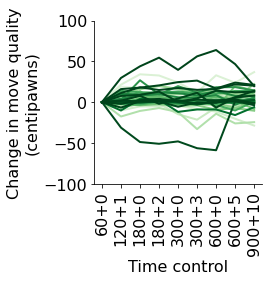

In [26]:
# Plot
fig, ax = plt.subplots(figsize=(3, 3))
cmap = plt.cm.Greens
for i in all_merged.keys():
    q = np.asarray(avg_quality_all[i])
    first_valid = next((v for v in q if not np.isnan(v)), np.nan)
    color = cmap(i / len(all_merged.keys()))
    ax.plot(list(xvals)[0:9], (q - first_valid)[0:9], color=color, lw=2)
ax.set_xlabel('Time control')
ax.set_ylabel('Change in move quality\n(centipawns)')
ax.set_xticks(list(xvals)[0:9])
ax.set_xticklabels(valid_controls[0:9])
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylim(-100, 100)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()
# plt.savefig('move_quality_scale.png', format='png', dpi=1000,bbox_inches = 'tight')

## Playing strength

In [27]:
# Compute averages as a function of time controls split by elo quantiles
avg_rts_high, avg_rts_low = {}, {}
avg_quality_high, avg_quality_low = {}, {}
entropy_high, entropy_low = {}, {}

for i in all_merged.keys():
    tcs_arr = np.asarray(pos_time_controls[i])
    elos_arr = np.asarray(pos_elos[i], dtype=float)
    rts_arr = np.asarray(pos_rts[i], dtype=float)
    moves_arr = np.asarray(pos_moves[i])
    q_arr = np.asarray(quality_scores_all[i], dtype=float)

    # Elo percentile thresholds
    p80 = np.nanpercentile(elos_arr, 80)
    p20 = np.nanpercentile(elos_arr, 20)
    high_mask = elos_arr >= p80
    low_mask = elos_arr <= p20

    rt_high, rt_low = [], []
    q_high, q_low = [], []
    ent_high, ent_low = [], []

    for tc in valid_controls:
        tc_mask = tcs_arr == tc

        # Move time
        rt_high.append(np.nanmean(rts_arr[tc_mask & high_mask]) if np.sum(tc_mask & high_mask) > 0 else np.nan)
        rt_low.append(np.nanmean(rts_arr[tc_mask & low_mask]) if np.sum(tc_mask & low_mask) > 0 else np.nan)

        # Move quality
        q_high.append(np.nanmean(q_arr[tc_mask & high_mask]) if np.sum(tc_mask & high_mask) > 0 else np.nan)
        q_low.append(np.nanmean(q_arr[tc_mask & low_mask]) if np.sum(tc_mask & low_mask) > 0 else np.nan)

        # Move entropy
        moves_high = moves_arr[tc_mask & high_mask]
        moves_low = moves_arr[tc_mask & low_mask]
        if len(moves_high) > 0:
            _, counts = np.unique(moves_high, return_counts=True)
            ent_high.append(stats.entropy(counts))
        else:
            ent_high.append(np.nan)
        if len(moves_low) > 0:
            _, counts = np.unique(moves_low, return_counts=True)
            ent_low.append(stats.entropy(counts))
        else:
            ent_low.append(np.nan)

    avg_rts_high[i], avg_rts_low[i] = rt_high, rt_low
    avg_quality_high[i], avg_quality_low[i] = q_high, q_low
    entropy_high[i], entropy_low[i] = ent_high, ent_low

/Users/ionatankuperwajs/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:31: RuntimeWarning: Mean of empty slice
/Users/ionatankuperwajs/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:32: RuntimeWarning: Mean of empty slice


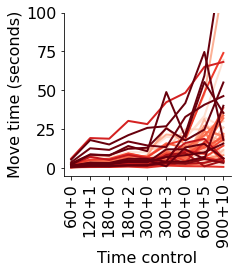

In [28]:
# Plot
fig, ax = plt.subplots(figsize=(3, 3))
cmap = plt.cm.Reds
for i in all_merged.keys():
    color = cmap(i / len(all_merged.keys()))
    ax.plot(list(xvals)[0:9], avg_rts_high[i][0:9], color=color, lw=2)
ax.set_xlabel('Time control')
ax.set_ylabel('Move time (seconds)')
ax.set_xticks(list(xvals)[0:9])
ax.set_xticklabels(valid_controls[0:9])
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylim(-5, 100)
ax.set_yticks([0, 25, 50, 75, 100])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()
# plt.savefig('move_time_elo_high_scale.png', format='png', dpi=1000,bbox_inches = 'tight')

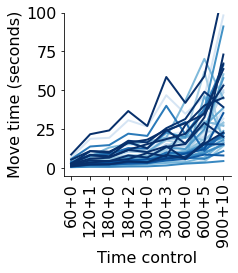

In [29]:
# Plot
fig, ax = plt.subplots(figsize=(3, 3))
cmap = plt.cm.Blues
for i in all_merged.keys():
    color = cmap(i / len(all_merged.keys()))
    ax.plot(list(xvals)[0:9], avg_rts_low[i][0:9], color=color, lw=2)
ax.set_xlabel('Time control')
ax.set_ylabel('Move time (seconds)')
ax.set_xticks(list(xvals)[0:9])
ax.set_xticklabels(valid_controls[0:9])
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylim(-5, 100)
ax.set_yticks([0, 25, 50, 75, 100])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()
# plt.savefig('move_time_elo_low_scale.png', format='png', dpi=1000,bbox_inches = 'tight')

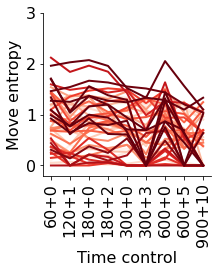

In [30]:
# Plot
fig, ax = plt.subplots(figsize=(3, 3))
cmap = plt.cm.Reds
for i in all_merged.keys():
    color = cmap(i / len(all_merged.keys()))
    ax.plot(list(xvals)[0:9], entropy_high[i][0:9], color=color, lw=2)
ax.set_xlabel('Time control')
ax.set_ylabel('Move entropy')
ax.set_xticks(list(xvals)[0:9])
ax.set_xticklabels(valid_controls[0:9])
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylim(-0.2, 3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()
# plt.savefig('move_entropy_elo_high_scale.png', format='png', dpi=1000,bbox_inches = 'tight')

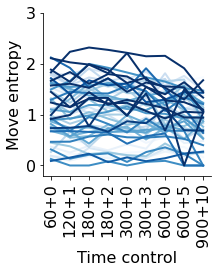

In [31]:
# Plot
fig, ax = plt.subplots(figsize=(3, 3))
cmap = plt.cm.Blues
for i in all_merged.keys():
    color = cmap(i / len(all_merged.keys()))
    ax.plot(list(xvals)[0:9], entropy_low[i][0:9], color=color, lw=2)
ax.set_xlabel('Time control')
ax.set_ylabel('Move entropy')
ax.set_xticks(list(xvals)[0:9])
ax.set_xticklabels(valid_controls[0:9])
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylim(-0.2, 3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()
# plt.savefig('move_entropy_elo_low_scale.png', format='png', dpi=1000,bbox_inches = 'tight')

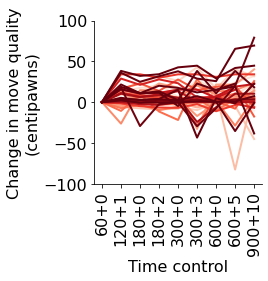

In [32]:
# Plot
fig, ax = plt.subplots(figsize=(3, 3))
cmap = plt.cm.Reds
for i in all_merged.keys():
    q = np.asarray(avg_quality_high[i])
    first_valid = next((v for v in q if not np.isnan(v)), np.nan)
    color = cmap(i / len(all_merged.keys()))
    ax.plot(list(xvals)[0:9], (q - first_valid)[0:9], color=color, lw=2)
ax.set_xlabel('Time control')
ax.set_ylabel('Change in move quality\n(centipawns)')
ax.set_xticks(list(xvals)[0:9])
ax.set_xticklabels(valid_controls[0:9])
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylim(-100, 100)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()
# plt.savefig('move_quality_elo_high_scale.png', format='png', dpi=1000,bbox_inches = 'tight')

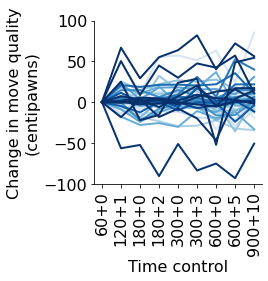

In [33]:
# Plot
fig, ax = plt.subplots(figsize=(3, 3))
cmap = plt.cm.Blues
for i in all_merged.keys():
    q = np.asarray(avg_quality_low[i])
    first_valid = next((v for v in q if not np.isnan(v)), np.nan)
    color = cmap(i / len(all_merged.keys()))
    ax.plot(list(xvals)[0:9], (q - first_valid)[0:9], color=color, lw=2)
ax.set_xlabel('Time control')
ax.set_ylabel('Change in move quality\n(centipawns)')
ax.set_xticks(list(xvals)[0:9])
ax.set_xticklabels(valid_controls[0:9])
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylim(-100, 100)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()
# plt.savefig('move_quality_elo_low_scale.png', format='png', dpi=1000,bbox_inches = 'tight')

## Comparison between variables

In [34]:
tc_index = list(range(len(valid_controls)))

slope_move_time, slope_move_entropy, slope_move_quality = [], [], []

for i in all_merged.keys():
    def get_slope(y_vals):
        pairs = [(x, y) for x, y in zip(tc_index, y_vals) if not np.isnan(y)]
        if len(pairs) < 2:
            return np.nan
        x_arr, y_arr = zip(*pairs)
        m, _ = np.polyfit(x_arr, y_arr, 1)
        return m

    slope_move_time.append(get_slope(avg_rts_all[i]))
    slope_move_entropy.append(get_slope(entropy_all[i]))
    slope_move_quality.append(get_slope(avg_quality_all[i]))

In [125]:
# Linear fit
x_arr = np.asarray(slope_move_entropy, dtype=float)
y_arr = np.asarray(slope_move_time, dtype=float)
mask = ~np.isnan(x_arr) & ~np.isnan(y_arr)
x_clean, y_clean = x_arr[mask], y_arr[mask]
m, b = np.polyfit(x_clean, y_clean, 1)
x_line = np.linspace(-0.14, 0.9, 100)
pearsonr(x_clean, y_clean)

(-0.27145887517618805, 0.04927327325919465)

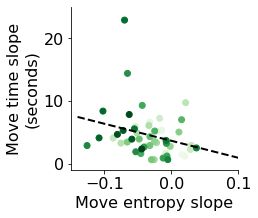

In [127]:
# Plot
fig, ax = plt.subplots(figsize=(3,3))
ax.scatter(slope_move_entropy, slope_move_time, c=list(range(1, len(all_merged.keys())+1)), cmap='Greens')
ax.plot(x_line, m * x_line + b, color='black', lw=2, ls='--')
ax.set_xlim(-0.15,0.1)
ax.set_ylim(-1,25)
ax.set_xlabel('Move entropy slope')
ax.set_ylabel('Move time slope\n(seconds)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()
# plt.savefig('entropy_time.png', format='png', dpi=1000,bbox_inches = 'tight')

In [122]:
# Linear fit
x_arr = np.asarray(slope_move_time, dtype=float)
y_arr = np.asarray(slope_move_quality, dtype=float)
mask = ~np.isnan(x_arr) & ~np.isnan(y_arr)
x_clean, y_clean = x_arr[mask], y_arr[mask]
m, b = np.polyfit(x_clean, y_clean, 1)
x_line = np.linspace(0, 24, 100)
pearsonr(x_clean, y_clean)

(0.3728312900005668, 0.005969924590694359)

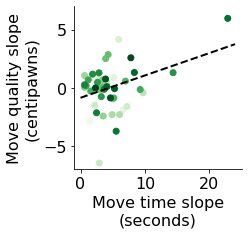

In [124]:
# Plot
fig, ax = plt.subplots(figsize=(3,3))
ax.scatter(slope_move_time, slope_move_quality, c=list(range(1, len(all_merged.keys())+1)), cmap='Greens')
ax.plot(x_line, m * x_line + b, color='black', lw=2, ls='--')
ax.set_xlim(-1, 25)
ax.set_ylim(-7, 7)
ax.set_xlabel('Move time slope\n(seconds)')
ax.set_ylabel('Move quality slope\n(centipawns)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()
# plt.savefig('time_quality.png', format='png', dpi=1000,bbox_inches = 'tight')

In [119]:
# Linear fit
x_arr = np.asarray(slope_move_entropy, dtype=float)
y_arr = np.asarray(slope_move_quality, dtype=float)
mask = ~np.isnan(x_arr) & ~np.isnan(y_arr)
x_clean, y_clean = x_arr[mask], y_arr[mask]
m, b = np.polyfit(x_clean, y_clean, 1)
x_line = np.linspace(-0.14, 0.09, 100)
pearsonr(x_clean, y_clean)

(-0.39745626849178917, 0.00320892874714236)

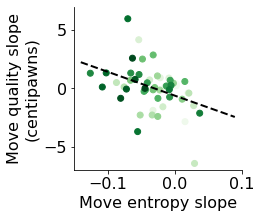

In [121]:
# Plot
fig, ax = plt.subplots(figsize=(3,3))
ax.scatter(slope_move_entropy, slope_move_quality, c=list(range(1, len(all_merged.keys())+1)), cmap='Greens')
ax.plot(x_line, m * x_line + b, color='black', lw=2, ls='--')
ax.set_xlim(-0.15,0.1)
ax.set_ylim(-7,7)
ax.set_xlabel('Move entropy slope')
ax.set_ylabel('Move quality slope\n(centipawns)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()
# plt.savefig('entropy_quality.png', format='png', dpi=1000,bbox_inches = 'tight')

## Plan complexity

In [ ]:
# Compute the number of pieces in the Stockfish principal variation for each position (excluding captures)
pv_noncapture_pieces_all = []

for i in all_merged.keys():
    if i >= len(fens) or not fens[i]:
        pv_noncapture_pieces_all.append(np.nan)
        continue

    board = chess.Board(fens[i])
    engine.configure({'Clear Hash': None})
    result = engine.analyse(board, chess.engine.Limit(depth=15))
    info = result[0] if isinstance(result, list) else result

    pv_moves = info['pv']
    planning_pieces = set()
    tactical_pieces = set()
    temp_board = chess.Board(fens[i])
    for move in pv_moves:
        piece = temp_board.piece_at(move.from_square)
        if piece:
            piece_id = (move.from_square, piece.piece_type)
            if temp_board.is_capture(move):
                tactical_pieces.add(piece_id)
            else:
                planning_pieces.add(piece_id)
        temp_board.push(move)

    # Count pieces that appear in non-capture moves only
    pure_planning = planning_pieces - tactical_pieces
    pv_noncapture_pieces_all.append(len(pure_planning))

In [116]:
# Linear fit
x_arr = np.asarray(pv_noncapture_pieces_all, dtype=float)
y_arr = np.asarray(slope_move_quality, dtype=float)
mask = ~np.isnan(x_arr) & ~np.isnan(y_arr)
x_clean, y_clean = x_arr[mask], y_arr[mask]
m, b = np.polyfit(x_clean, y_clean, 1)
x_line = np.linspace(4.5, 15.5, 100)
pearsonr(x_clean, y_clean)

(0.26308610210927647, 0.05700091763332104)

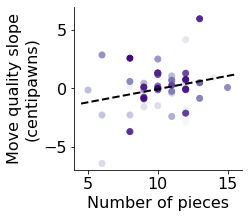

In [118]:
# Plot
fig, ax = plt.subplots(figsize=(3,3))
ax.scatter(pv_noncapture_pieces_all, slope_move_quality, c=list(range(1, len(all_merged.keys())+1)), cmap='Purples')
ax.plot(x_line, m * x_line + b, color='black', lw=2, ls='--')
ax.set_xlim(4,16)
ax.set_ylim(-7,7)
ax.set_xlabel('Number of pieces')
ax.set_ylabel('Move quality slope\n(centipawns)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()
# plt.savefig('plan_complexity.png', format='png', dpi=1000,bbox_inches = 'tight')

In [ ]:
# Close the engine
engine.quit()